# Full Pipeline 05: Evaluation and Backtest (Load-Only)

This notebook evaluates saved RL action files against baseline policies.

It does not train or fine-tune models.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "evaluation").exists() and (candidate / "full_pipeline").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repo root.")

PIPELINE_ROOT = REPO_ROOT / "full_pipeline"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from evaluation import (
    BacktestEngine,
    EvaluationConfig,
    all_baseline_policies,
    bootstrap_metric_table,
    default_action_space,
    load_default_dataset,
    plot_equity_curves,
    summary_table,
)
from _pipeline_utils import OUTPUT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

In [2]:
state_path = OUTPUT_DIR / "model_state_weekly_hmm_news.csv"

# Prefer finetuned canonical files if present.
validation_actions_path = OUTPUT_DIR / "rl_validation_actions.csv"
locked_test_actions_path = OUTPUT_DIR / "rl_locked_test_actions.csv"
if (OUTPUT_DIR / "rl_validation_actions_finetuned.csv").exists():
    validation_actions_path = OUTPUT_DIR / "rl_validation_actions_finetuned.csv"
if (OUTPUT_DIR / "rl_locked_test_actions_finetuned.csv").exists():
    locked_test_actions_path = OUTPUT_DIR / "rl_locked_test_actions_finetuned.csv"

def _load_dataset_resilient(path: Path):
    try:
        return load_default_dataset(path), path
    except ValueError as exc:
        # Common issue: headers in exported CSV can contain extra spaces (e.g., "week_end  ").
        if "parse_dates" not in str(exc) or "week_end" not in str(exc):
            raise

        raw = pd.read_csv(path)
        raw.columns = [str(col).strip() for col in raw.columns]

        if "week_end" not in raw.columns:
            raise ValueError(
                f"Could not recover 'week_end' column from {path}. Available columns: {list(raw.columns)[:12]}"
            )

        cleaned_path = OUTPUT_DIR / "model_state_weekly_hmm_news_header_fixed.csv"
        raw.to_csv(cleaned_path, index=False)
        return load_default_dataset(cleaned_path), cleaned_path

dataset, dataset_path_used = _load_dataset_resilient(state_path)
action_space = default_action_space()
engine = BacktestEngine(
    dataset=dataset,
    action_space=action_space,
    config=EvaluationConfig(transaction_cost=0.001, risk_penalty=0.05, risk_window=12),
)

display(dataset.describe_splits())
display(dataset.describe_feature_blocks())
print("State file:", dataset_path_used.relative_to(REPO_ROOT))
print("Validation actions file:", validation_actions_path.relative_to(REPO_ROOT))
print("Locked-test actions file:", locked_test_actions_path.relative_to(REPO_ROOT))

,split,rows,start,end
0,warmup,14,2014-03-28,2014-06-27
1,train,339,2014-07-04,2020-12-25
2,validation,105,2021-01-01,2022-12-30
3,locked_test,167,2023-01-06,2026-03-13


,block,n_columns,example_columns
0,price,35,"spy_ret_1d, spy_ret_5d, spy_ret_20d, spy_vol_5..."
1,macro,31,"bamlh0a0hym2_level, bamlh0a0hym2_chg_5d, cfnai..."
2,regime,4,"regime_filtered, regime_viterbi, filtered_prob..."
3,text,5,"news_finbert_compound_spy, news_finbert_compou..."


State file: output/full_pipeline/model_state_weekly_hmm_news_header_fixed.csv
Validation actions file: output/full_pipeline/rl_validation_actions_finetuned.csv
Locked-test actions file: output/full_pipeline/rl_locked_test_actions_finetuned.csv


In [3]:
include_blocks = ("price", "macro", "regime", "text")
baselines = all_baseline_policies(action_space)

validation_results = engine.run_many(baselines, split="validation", include_blocks=include_blocks)
locked_test_results = engine.run_many(baselines, split="locked_test", include_blocks=include_blocks)

print("Validation summary")
display(summary_table(validation_results))
print("Locked-test summary")
display(summary_table(locked_test_results))

Validation summary


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,105.0,0.018391,0.009066,0.001812,4.982270,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000172
1,spy_only,105.0,0.067832,0.033037,0.184064,0.268378,0.468450,-0.239272,0.138072,0.009524,0.0010,0.514286,-0.000206
2,momentum_rotation_20d,105.0,0.010368,0.005121,0.132257,0.104621,0.164405,-0.161091,0.031792,0.409524,0.0430,0.552381,-0.000543
3,spy_80_tlt_20,105.0,-0.011772,-0.005848,0.152120,0.037388,0.063366,-0.252807,-0.023130,0.009524,0.0010,0.514286,-0.000815
4,gld_only,105.0,-0.027073,-0.013500,0.133363,-0.034920,-0.051379,-0.173483,-0.077820,0.009524,0.0010,0.533333,-0.000950
5,balanced_60_30_10,105.0,-0.057889,-0.029100,0.126170,-0.170990,-0.288991,-0.247677,-0.117494,0.009524,0.0010,0.523810,-0.001160
6,heuristic_regime_proxy,105.0,-0.105252,-0.053588,0.137587,-0.331424,-0.590688,-0.252506,-0.212223,0.186667,0.0196,0.504762,-0.001642
7,equal_weight_spy_tlt_gld,105.0,-0.090055,-0.045661,0.102505,-0.404583,-0.723780,-0.221510,-0.206135,0.009524,0.0010,0.533333,-0.001401
8,defensive_20_60_20,105.0,-0.180898,-0.094097,0.111258,-0.831821,-1.384266,-0.284818,-0.330375,0.009524,0.0010,0.447619,-0.002410
9,tlt_only,105.0,-0.307662,-0.166474,0.158525,-1.067074,-1.699467,-0.391149,-0.425602,0.009524,0.0010,0.447619,-0.004178


Locked-test summary


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,167.0,0.163555,0.048298,0.000787,59.983868,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000907
1,gld_only,167.0,1.377401,0.309513,0.171184,1.664837,2.498113,-0.145468,2.127708,0.005988,0.0010,0.586826,0.004476
2,equal_weight_spy_tlt_gld,167.0,0.598671,0.157300,0.096691,1.561292,2.707431,-0.092219,1.705727,0.005988,0.0010,0.574850,0.002301
3,balanced_60_30_10,167.0,0.510345,0.136999,0.102350,1.307084,2.288772,-0.100816,1.358911,0.005988,0.0010,0.580838,0.001914
4,spy_only,167.0,0.741621,0.188577,0.141179,1.296514,1.855163,-0.168772,1.117353,0.005988,0.0010,0.574850,0.002633
5,spy_80_tlt_20,167.0,0.548197,0.145797,0.119400,1.201034,1.909304,-0.131781,1.106355,0.005988,0.0010,0.562874,0.001995
6,momentum_rotation_20d,167.0,0.700984,0.179872,0.156569,1.136594,1.523746,-0.148595,1.210486,0.317365,0.0530,0.592814,0.002526
7,defensive_20_60_20,167.0,0.289940,0.082502,0.101908,0.829378,1.487001,-0.134524,0.613290,0.005988,0.0010,0.544910,0.000984
8,heuristic_regime_proxy,167.0,0.232153,0.067163,0.113768,0.629576,0.764472,-0.147037,0.456780,0.232934,0.0389,0.574850,0.000736
9,tlt_only,167.0,-0.076144,-0.024359,0.137876,-0.109841,-0.174408,-0.220038,-0.110704,0.005988,0.0010,0.491018,-0.001170


In [4]:
validation_target = dataset.subset("validation").frame
locked_test_target = dataset.subset("locked_test").frame

# Evaluate all available RL policy action files (explicitly including A2C and PPO).
policy_action_candidates = {
    "rl_finetuned_best": {
        "validation": [validation_actions_path],
        "locked_test": [locked_test_actions_path],
    },
    "dqn": {
        "validation": [
            OUTPUT_DIR / "dqn_validation_actions_finetuned.csv",
            OUTPUT_DIR / "dqn_validation_actions.csv",
        ],
        "locked_test": [
            OUTPUT_DIR / "dqn_locked_test_actions_finetuned.csv",
            OUTPUT_DIR / "dqn_locked_test_actions.csv",
        ],
    },
    "a2c": {
        "validation": [
            OUTPUT_DIR / "a2c_validation_actions_finetuned.csv",
            OUTPUT_DIR / "a2c_validation_actions.csv",
        ],
        "locked_test": [
            OUTPUT_DIR / "a2c_locked_test_actions_finetuned.csv",
            OUTPUT_DIR / "a2c_locked_test_actions.csv",
        ],
    },
    "ppo": {
        "validation": [
            OUTPUT_DIR / "ppo_validation_actions_finetuned.csv",
            OUTPUT_DIR / "ppo_validation_actions.csv",
        ],
        "locked_test": [
            OUTPUT_DIR / "ppo_locked_test_actions_finetuned.csv",
            OUTPUT_DIR / "ppo_locked_test_actions.csv",
        ],
    },
    "attention_dqn": {
        "validation": [
            OUTPUT_DIR / "attention_dqn_validation_actions_finetuned.csv",
            OUTPUT_DIR / "attention_dqn_validation_actions.csv",
        ],
        "locked_test": [
            OUTPUT_DIR / "attention_dqn_locked_test_actions_finetuned.csv",
            OUTPUT_DIR / "attention_dqn_locked_test_actions.csv",
        ],
    },
}

def _first_existing(paths):
    return next((p for p in paths if p.exists()), None)

rl_validation_results = []
rl_locked_test_results = []
loaded_policy_rows = []
missing_policies = []

for policy_name, candidates in policy_action_candidates.items():
    val_path = _first_existing(candidates["validation"])
    test_path = _first_existing(candidates["locked_test"])
    if val_path is None or test_path is None:
        missing_policies.append(policy_name)
        continue

    val_actions = pd.read_csv(val_path, parse_dates=["week_end"])
    test_actions = pd.read_csv(test_path, parse_dates=["week_end"])

    assert len(val_actions) == len(validation_target), f"Validation action count mismatch for {policy_name}."
    assert len(test_actions) == len(locked_test_target), f"Locked-test action count mismatch for {policy_name}."

    label = f"rl_{policy_name}"
    rl_val = engine.evaluate_precomputed_actions(
        action_ids=val_actions["action_id"],
        split="validation",
        include_blocks=include_blocks,
        name=label,
    )
    rl_test = engine.evaluate_precomputed_actions(
        action_ids=test_actions["action_id"],
        split="locked_test",
        include_blocks=include_blocks,
        name=label,
    )

    rl_validation_results.append(rl_val)
    rl_locked_test_results.append(rl_test)
    loaded_policy_rows.append(
        {
            "policy": policy_name,
            "validation_actions": str(val_path.relative_to(REPO_ROOT)),
            "locked_test_actions": str(test_path.relative_to(REPO_ROOT)),
        }
    )

if not rl_validation_results or not rl_locked_test_results:
    raise ValueError("No RL policy action files found. Run Notebook 04 export cell first.")

# Backward-compatible aliases used by later cells.
best_alias = next((r for r in rl_locked_test_results if r.name == "rl_rl_finetuned_best"), None)
if best_alias is None:
    best_alias = rl_locked_test_results[0]
rl_locked_test = best_alias
rl_validation = next(
    (r for r in rl_validation_results if r.name == rl_locked_test.name.replace("locked_test", "validation")),
    rl_validation_results[0],
)

combined_validation = summary_table(validation_results + rl_validation_results)
combined_locked_test = summary_table(locked_test_results + rl_locked_test_results)

print("Loaded RL policy action files")
display(pd.DataFrame(loaded_policy_rows))

if missing_policies:
    print("Missing RL policy action files:", ", ".join(missing_policies))

print("Validation summary with RL policies")
display(combined_validation)
print("Locked-test summary with RL policies")
display(combined_locked_test)

Loaded RL policy action files


,policy,validation_actions,locked_test_actions
0,rl_finetuned_best,output/full_pipeline/rl_validation_actions_fin...,output/full_pipeline/rl_locked_test_actions_fi...
1,dqn,output/full_pipeline/dqn_validation_actions_fi...,output/full_pipeline/dqn_locked_test_actions_f...
2,a2c,output/full_pipeline/a2c_validation_actions_fi...,output/full_pipeline/a2c_locked_test_actions_f...
3,ppo,output/full_pipeline/ppo_validation_actions_fi...,output/full_pipeline/ppo_locked_test_actions_f...
4,attention_dqn,output/full_pipeline/attention_dqn_validation_...,output/full_pipeline/attention_dqn_locked_test...


Validation summary with RL policies


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,105.0,0.018391,0.009066,0.001812,4.982270,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000172
1,spy_only,105.0,0.067832,0.033037,0.184064,0.268378,0.468450,-0.239272,0.138072,0.009524,0.0010,0.514286,-0.000206
2,rl_a2c,105.0,0.031916,0.015681,0.155034,0.177856,0.295901,-0.244539,0.064124,0.563810,0.0592,0.523810,-0.000435
3,rl_rl_finetuned_best,105.0,0.010289,0.005082,0.172818,0.115416,0.178498,-0.226365,0.022452,0.325714,0.0342,0.495238,-0.000636
4,rl_attention_dqn,105.0,0.010289,0.005082,0.172818,0.115416,0.178498,-0.226365,0.022452,0.325714,0.0342,0.495238,-0.000636
5,momentum_rotation_20d,105.0,0.010368,0.005121,0.132257,0.104621,0.164405,-0.161091,0.031792,0.409524,0.0430,0.552381,-0.000543
6,spy_80_tlt_20,105.0,-0.011772,-0.005848,0.152120,0.037388,0.063366,-0.252807,-0.023130,0.009524,0.0010,0.514286,-0.000815
7,gld_only,105.0,-0.027073,-0.013500,0.133363,-0.034920,-0.051379,-0.173483,-0.077820,0.009524,0.0010,0.533333,-0.000950
8,balanced_60_30_10,105.0,-0.057889,-0.029100,0.126170,-0.170990,-0.288991,-0.247677,-0.117494,0.009524,0.0010,0.523810,-0.001160
9,rl_dqn,105.0,-0.117065,-0.059797,0.168761,-0.281266,-0.492714,-0.255108,-0.234398,0.340952,0.0358,0.447619,-0.001911


Locked-test summary with RL policies


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,167.0,0.163555,0.048298,0.000787,59.983868,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000907
1,gld_only,167.0,1.377401,0.309513,0.171184,1.664837,2.498113,-0.145468,2.127708,0.005988,0.0010,0.586826,0.004476
2,equal_weight_spy_tlt_gld,167.0,0.598671,0.157300,0.096691,1.561292,2.707431,-0.092219,1.705727,0.005988,0.0010,0.574850,0.002301
3,rl_dqn,167.0,0.754789,0.191369,0.133526,1.380469,1.741600,-0.126764,1.509640,0.394012,0.0658,0.628743,0.002723
4,balanced_60_30_10,167.0,0.510345,0.136999,0.102350,1.307084,2.288772,-0.100816,1.358911,0.005988,0.0010,0.580838,0.001914
5,spy_only,167.0,0.741621,0.188577,0.141179,1.296514,1.855163,-0.168772,1.117353,0.005988,0.0010,0.574850,0.002633
6,rl_rl_finetuned_best,167.0,0.748185,0.189970,0.154822,1.202138,1.999435,-0.187912,1.010955,0.388024,0.0648,0.556886,0.002620
7,rl_attention_dqn,167.0,0.748185,0.189970,0.154822,1.202138,1.999435,-0.187912,1.010955,0.388024,0.0648,0.556886,0.002620
8,spy_80_tlt_20,167.0,0.548197,0.145797,0.119400,1.201034,1.909304,-0.131781,1.106355,0.005988,0.0010,0.562874,0.001995
9,momentum_rotation_20d,167.0,0.700984,0.179872,0.156569,1.136594,1.523746,-0.148595,1.210486,0.317365,0.0530,0.592814,0.002526


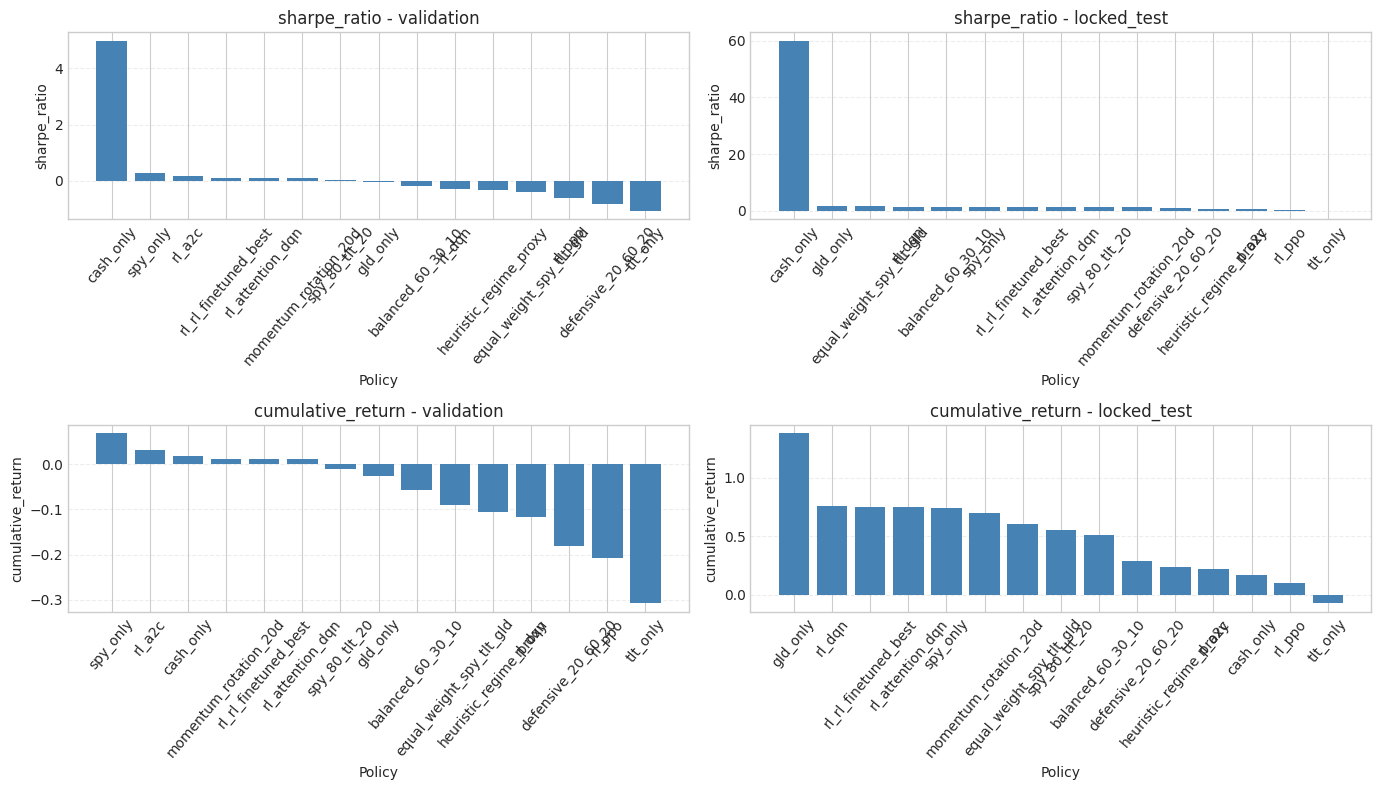

In [5]:
# Plot all policies (baselines + RL) for quick comparison across splits.
plot_val = combined_validation.copy()
plot_val["split"] = "validation"
plot_test = combined_locked_test.copy()
plot_test["split"] = "locked_test"
plot_df = pd.concat([plot_val, plot_test], ignore_index=False)

# summary_table may keep policy labels in a column (name/policy) or in index.
plot_df = plot_df.reset_index()
label_candidates = ["name", "policy", "strategy", "index"]
label_col = next((col for col in label_candidates if col in plot_df.columns), None)
if label_col is None:
    raise ValueError(f"Could not find policy label column. Available columns: {list(plot_df.columns)}")
plot_df = plot_df.rename(columns={label_col: "policy_label"})

required_cols = {"policy_label", "split", "sharpe_ratio", "cumulative_return"}
missing_cols = required_cols.difference(plot_df.columns)
if missing_cols:
    raise ValueError(f"Missing columns for plotting: {sorted(missing_cols)}")

plot_df = plot_df[["policy_label", "split", "sharpe_ratio", "cumulative_return"]].copy()
plot_df["policy_label"] = plot_df["policy_label"].astype(str)

metrics = ["sharpe_ratio", "cumulative_return"]
splits = ["validation", "locked_test"]
fig, axes = plt.subplots(len(metrics), len(splits), figsize=(14, 8), squeeze=False)

for i, metric in enumerate(metrics):
    for j, split_name in enumerate(splits):
        ax = axes[i, j]
        subset = plot_df.loc[plot_df["split"] == split_name].sort_values(metric, ascending=False)

        ax.bar(subset["policy_label"], subset[metric], color="steelblue")
        ax.set_title(f"{metric} - {split_name}")
        ax.set_xlabel("Policy")
        ax.set_ylabel(metric)
        ax.tick_params(axis="x", rotation=50)
        ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.tight_layout()
plt.show()

,strategy,sharpe_ratio_ci_low,sharpe_ratio_ci_high
0,cash_only,56.058890,65.064479
1,spy_only,0.189675,2.554732
2,tlt_only,-1.140880,0.958184
3,gld_only,0.554777,3.040424
4,spy_80_tlt_20,0.145479,2.448081
5,balanced_60_30_10,0.259623,2.545744
6,defensive_20_60_20,-0.092637,2.033621
7,equal_weight_spy_tlt_gld,0.621584,2.830327
8,momentum_rotation_20d,0.086392,2.444338
9,heuristic_regime_proxy,-0.404168,2.045210


Validation policies: ['cash_only', 'spy_only', 'tlt_only', 'gld_only', 'spy_80_tlt_20', 'balanced_60_30_10', 'defensive_20_60_20', 'equal_weight_spy_tlt_gld', 'momentum_rotation_20d', 'heuristic_regime_proxy', 'rl_rl_finetuned_best', 'rl_dqn', 'rl_a2c', 'rl_ppo', 'rl_attention_dqn']
Locked-test policies: ['cash_only', 'spy_only', 'tlt_only', 'gld_only', 'spy_80_tlt_20', 'balanced_60_30_10', 'defensive_20_60_20', 'equal_weight_spy_tlt_gld', 'momentum_rotation_20d', 'heuristic_regime_proxy', 'rl_rl_finetuned_best', 'rl_dqn', 'rl_a2c', 'rl_ppo', 'rl_attention_dqn']


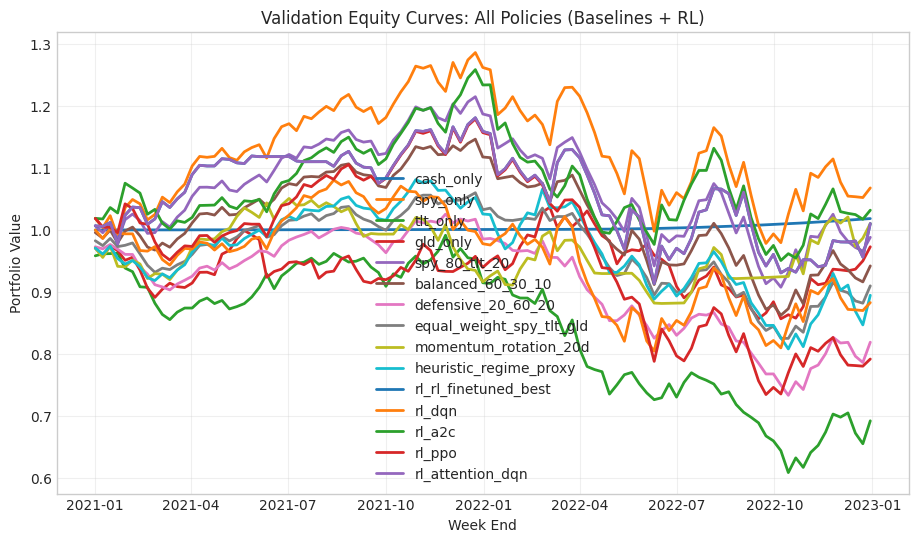

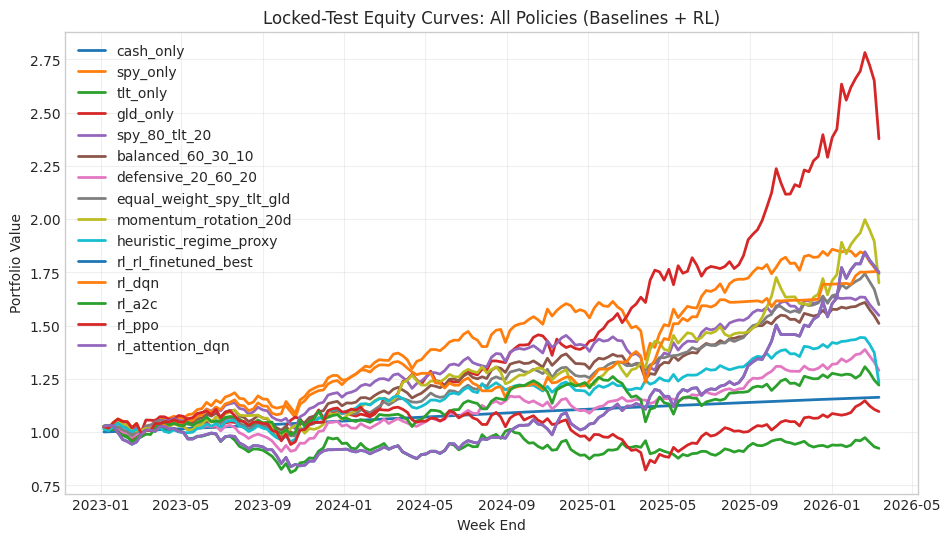

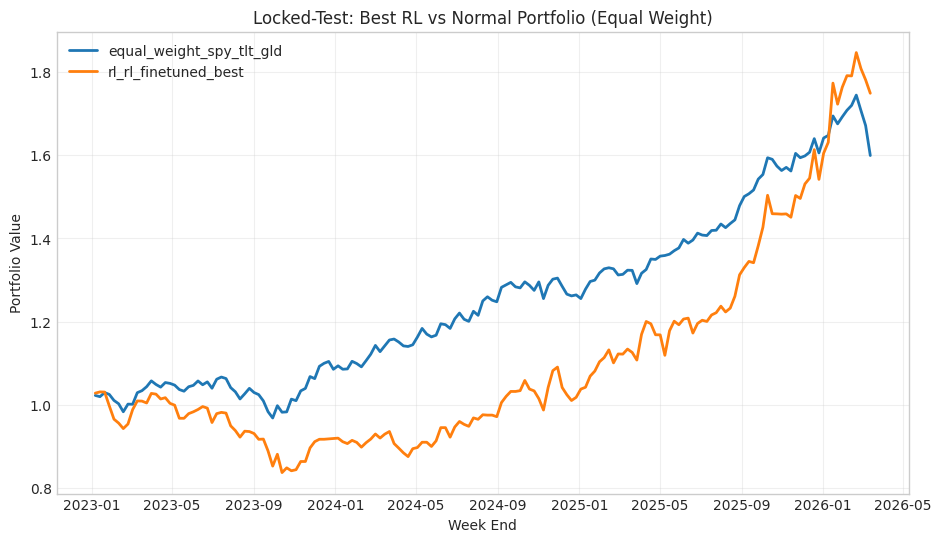

In [6]:
all_validation_results = validation_results + rl_validation_results
all_locked_results = locked_test_results + rl_locked_test_results

display(bootstrap_metric_table(all_locked_results, metric="sharpe_ratio", n_boot=300, seed=7))

print("Validation policies:", [r.name for r in all_validation_results])
print("Locked-test policies:", [r.name for r in all_locked_results])

# Compare all policies on validation.
plot_equity_curves(
    all_validation_results,
    title="Validation Equity Curves: All Policies (Baselines + RL)",
)
plt.show()

# Compare all policies on locked test.
plot_equity_curves(
    all_locked_results,
    title="Locked-Test Equity Curves: All Policies (Baselines + RL)",
)
plt.show()

# Focused comparison: normal portfolio (equal-weight) vs best RL policy alias.
normal_name = "equal_weight_spy_tlt_gld"
normal_results = [result for result in locked_test_results if result.name == normal_name]
best_rl = next((r for r in rl_locked_test_results if r.name == "rl_rl_finetuned_best"), rl_locked_test_results[0])
focused = normal_results + [best_rl]

if len(focused) >= 2:
    plot_equity_curves(focused, title="Locked-Test: Best RL vs Normal Portfolio (Equal Weight)")
    plt.show()
else:
    print(f"Normal portfolio baseline '{normal_name}' not found in locked_test_results.")

In [7]:
# Action mix for canonical/best RL action files used by this notebook.
validation_actions = pd.read_csv(validation_actions_path, parse_dates=["week_end"])

locked_test_actions = pd.read_csv(locked_test_actions_path, parse_dates=["week_end"])


action_mix = pd.DataFrame(
    {
        "validation": validation_actions["action_name"].value_counts(),
        "locked_test": locked_test_actions["action_name"].value_counts(),
    }
).fillna(0).astype(int)
display(action_mix)

,validation,locked_test
action_name,,
balanced_60_30_10,1,0
cash_only,20,10
defensive_20_60_20,2,1
gld_only,10,81
spy_80_tlt_20,5,0
spy_only,62,6
tlt_only,5,69


In [10]:
# Export weekly RL predictions for train/validation/locked_test from finetuned checkpoints.
from stable_baselines3 import A2C, DQN, PPO

from ml.agents import AttentionDQNAgent
from ml.hyperparameter_config import load_hyperparameter_config
from _pipeline_utils import make_rl_env, prepare_rl_inputs, rollout_agent_on_split

CONFIG_PATH = REPO_ROOT / "configs" / "rl_hyperparameters.yaml"
HP_CONFIG = load_hyperparameter_config(CONFIG_PATH, fast_mode=False)
CFG = HP_CONFIG.values

SEQ_LEN = int(CFG["general"]["sequence_length"])
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

prepared_rl = prepare_rl_inputs(state_path=dataset_path_used)
frame_all = prepared_rl["frame"]

rollout_config = EvaluationConfig(
    transaction_cost=float(CFG["environment"]["transaction_cost"]),
    risk_penalty=float(CFG["environment"]["volatility_penalty"]),
    risk_window=int(CFG["environment"]["lookback_vol"]),
)

class AttentionPredictAdapter:
    def __init__(self, attn_agent):
        self.attn_agent = attn_agent

    def predict(self, obs, deterministic=True):
        action = self.attn_agent.select_action(obs, training=False)
        return action, None


policy_specs = {
    "dqn": {
        "kind": "sb3",
        "algo": DQN,
        "checkpoints": [
            OUTPUT_DIR / "dqn_hmm_news_finetuned.zip",
            OUTPUT_DIR / "dqn_hmm_news_base.zip",
            REPO_ROOT / "output" / "models" / "dqn_agent.zip",
        ],
    },
    "a2c": {
        "kind": "sb3",
        "algo": A2C,
        "checkpoints": [
            OUTPUT_DIR / "a2c_hmm_news_finetuned.zip",
            OUTPUT_DIR / "a2c_hmm_news_base.zip",
            REPO_ROOT / "output" / "models" / "a2c_agent.zip",
        ],
    },
    "ppo": {
        "kind": "sb3",
        "algo": PPO,
        "checkpoints": [
            OUTPUT_DIR / "ppo_hmm_news_finetuned.zip",
            OUTPUT_DIR / "ppo_hmm_news_base.zip",
            REPO_ROOT / "output" / "models" / "ppo_agent.zip",
        ],
    },
    "attention_dqn": {
        "kind": "attention",
        "checkpoints": [
            OUTPUT_DIR / "attention_dqn_hmm_news_finetuned.pt",
            OUTPUT_DIR / "attention_dqn_hmm_news_base.pt",
            REPO_ROOT / "output" / "models" / "attention_dqn_agent.pt",
        ],
    },
}

split_names = ["train", "validation", "locked_test"]
export_rows = []

for policy_name, spec in policy_specs.items():
    ckpt_path = next((p for p in spec["checkpoints"] if p.exists()), None)
    if ckpt_path is None:
        export_rows.append({"policy": policy_name, "status": "missing_checkpoint", "checkpoint": ""})
        continue

    if spec["kind"] == "sb3":
        model = spec["algo"].load(str(ckpt_path), device=DEVICE)
        predictor = model
    else:
        sample_env = make_rl_env(prepared_rl, split="validation", seq_len=SEQ_LEN, config=rollout_config)
        state_dim = int(sample_env.observation_space.shape[-1])
        action_dim = int(sample_env.action_space.n)
        agent = AttentionDQNAgent(
            state_dim=state_dim,
            action_dim=action_dim,
            seq_len=SEQ_LEN,
            learning_rate=float(CFG["dqn"]["learning_rate"]),
            gamma=float(CFG["dqn"]["gamma"]),
            epsilon_start=float(CFG["dqn"]["exploration_initial_eps"]),
            epsilon_end=float(CFG["dqn"]["exploration_final_eps"]),
            epsilon_decay=3000,
            buffer_capacity=int(CFG["dqn"]["buffer_size"]),
            batch_size=int(CFG["dqn"]["batch_size"]),
            target_update_freq=max(250, int(CFG["dqn"]["target_update_interval"] // 4)),
            use_dueling=True,
            device=DEVICE,
        )
        agent.load_checkpoint(str(ckpt_path))
        predictor = AttentionPredictAdapter(agent)

    for split_name in split_names:
        env = make_rl_env(prepared_rl, split=split_name, seq_len=SEQ_LEN, config=rollout_config)
        action_frame = rollout_agent_on_split(predictor, env, frame_all, split=split_name)

        out_path = OUTPUT_DIR / f"{policy_name}_{split_name}_actions_finetuned.csv"
        action_frame.to_csv(out_path, index=False)

        export_rows.append(
            {
                "policy": policy_name,
                "split": split_name,
                "rows": int(len(action_frame)),
                "checkpoint": str(ckpt_path.relative_to(REPO_ROOT)),
                "output": str(out_path.relative_to(REPO_ROOT)),
                "status": "ok",
            }
        )

        # Friendly alias: save locked_test also as test.
        if split_name == "locked_test":
            test_alias_path = OUTPUT_DIR / f"{policy_name}_test_actions_finetuned.csv"
            action_frame.to_csv(test_alias_path, index=False)
            export_rows.append(
                {
                    "policy": policy_name,
                    "split": "test_alias",
                    "rows": int(len(action_frame)),
                    "checkpoint": str(ckpt_path.relative_to(REPO_ROOT)),
                    "output": str(test_alias_path.relative_to(REPO_ROOT)),
                    "status": "ok",
                }
            )

export_df = pd.DataFrame(export_rows)
print("Exported weekly action files (train/validation/locked_test + test alias):")
display(export_df)

# Keep backward-compatible aliases for downstream save cell.
if "export_df" in globals() and not export_df.empty:
    loaded_policy_rows = export_df.loc[export_df["status"] == "ok", ["policy", "split", "output"]].to_dict("records")

Checkpoint loaded from /home/yuaylong/Market-Regime-Detection-for-RL-Allocation/output/full_pipeline/attention_dqn_hmm_news_finetuned.pt
Exported weekly action files (train/validation/locked_test + test alias):


,policy,split,rows,checkpoint,output,status
0,dqn,train,339,output/full_pipeline/dqn_hmm_news_finetuned.zip,output/full_pipeline/dqn_train_actions_finetun...,ok
1,dqn,validation,105,output/full_pipeline/dqn_hmm_news_finetuned.zip,output/full_pipeline/dqn_validation_actions_fi...,ok
2,dqn,locked_test,167,output/full_pipeline/dqn_hmm_news_finetuned.zip,output/full_pipeline/dqn_locked_test_actions_f...,ok
3,dqn,test_alias,167,output/full_pipeline/dqn_hmm_news_finetuned.zip,output/full_pipeline/dqn_test_actions_finetune...,ok
4,a2c,train,339,output/full_pipeline/a2c_hmm_news_finetuned.zip,output/full_pipeline/a2c_train_actions_finetun...,ok
5,a2c,validation,105,output/full_pipeline/a2c_hmm_news_finetuned.zip,output/full_pipeline/a2c_validation_actions_fi...,ok
6,a2c,locked_test,167,output/full_pipeline/a2c_hmm_news_finetuned.zip,output/full_pipeline/a2c_locked_test_actions_f...,ok
7,a2c,test_alias,167,output/full_pipeline/a2c_hmm_news_finetuned.zip,output/full_pipeline/a2c_test_actions_finetune...,ok
8,ppo,train,339,output/full_pipeline/ppo_hmm_news_finetuned.zip,output/full_pipeline/ppo_train_actions_finetun...,ok
9,ppo,validation,105,output/full_pipeline/ppo_hmm_news_finetuned.zip,output/full_pipeline/ppo_validation_actions_fi...,ok


In [8]:
# Save key outputs (tables + figures) to disk.
save_dir = OUTPUT_DIR / "evaluation_backtest_artifacts"
save_dir.mkdir(parents=True, exist_ok=True)

saved_files = []

if "combined_validation" in globals():
    path = save_dir / "summary_validation_all_policies.csv"
    combined_validation.to_csv(path)
    saved_files.append(path)

if "combined_locked_test" in globals():
    path = save_dir / "summary_locked_test_all_policies.csv"
    combined_locked_test.to_csv(path)
    saved_files.append(path)

if "action_mix" in globals():
    path = save_dir / "action_mix_best_rl.csv"
    action_mix.to_csv(path)
    saved_files.append(path)

if "loaded_policy_rows" in globals():
    path = save_dir / "loaded_rl_action_files.csv"
    pd.DataFrame(loaded_policy_rows).to_csv(path, index=False)
    saved_files.append(path)

if "all_validation_results" in globals():
    plot_equity_curves(
        all_validation_results,
        title="Validation Equity Curves: All Policies (Baselines + RL)",
    )
    fig_path = save_dir / "equity_curves_validation_all_policies.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close()
    saved_files.append(fig_path)

if "all_locked_results" in globals():
    plot_equity_curves(
        all_locked_results,
        title="Locked-Test Equity Curves: All Policies (Baselines + RL)",
    )
    fig_path = save_dir / "equity_curves_locked_test_all_policies.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close()
    saved_files.append(fig_path)

if "locked_test_results" in globals() and "rl_locked_test_results" in globals() and rl_locked_test_results:
    normal_name = "equal_weight_spy_tlt_gld"
    normal_results = [r for r in locked_test_results if r.name == normal_name]
    best_rl = next((r for r in rl_locked_test_results if r.name == "rl_rl_finetuned_best"), rl_locked_test_results[0])
    focused = normal_results + [best_rl]
    if len(focused) >= 2:
        plot_equity_curves(focused, title="Locked-Test: Best RL vs Normal Portfolio (Equal Weight)")
        fig_path = save_dir / "equity_curves_locked_test_best_rl_vs_normal.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.close()
        saved_files.append(fig_path)

manifest_path = save_dir / "artifacts_manifest.txt"
manifest_path.write_text("\n".join(str(p.relative_to(REPO_ROOT)) for p in saved_files) + "\n", encoding="utf-8")
saved_files.append(manifest_path)

print("Saved artifacts:")
for p in saved_files:
    print("-", p.relative_to(REPO_ROOT))

Saved artifacts:
- output/full_pipeline/evaluation_backtest_artifacts/summary_validation_all_policies.csv
- output/full_pipeline/evaluation_backtest_artifacts/summary_locked_test_all_policies.csv
- output/full_pipeline/evaluation_backtest_artifacts/action_mix_best_rl.csv
- output/full_pipeline/evaluation_backtest_artifacts/loaded_rl_action_files.csv
- output/full_pipeline/evaluation_backtest_artifacts/equity_curves_validation_all_policies.png
- output/full_pipeline/evaluation_backtest_artifacts/equity_curves_locked_test_all_policies.png
- output/full_pipeline/evaluation_backtest_artifacts/equity_curves_locked_test_best_rl_vs_normal.png
- output/full_pipeline/evaluation_backtest_artifacts/artifacts_manifest.txt
